In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv('zomato.csv')
print("Dataset Loaded Successfully")
print("Shape of dataset:", df.shape)
display(df.head())

Dataset Loaded Successfully
Shape of dataset: (148, 7)


,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


In [77]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


In [78]:
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


,0
name,0
online_order,0
book_table,0
rate,0
votes,0
approx_cost(for two people),0
listed_in(type),0


In [79]:
print("Columns in Dataset:")
df.columns

Columns in Dataset:


Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [80]:
df = df.drop_duplicates()

In [81]:
df.columns = df.columns.str.strip()

In [82]:
df['rate'] = df['rate'].replace('NEW', np.nan)
df['rate'] = df['rate'].astype(str).str.replace('/5', '').astype(float)
df.rate

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8
...,...
143,3.3
144,3.3
145,4.0
146,3.0


In [83]:
df['approx_cost(for two people)'] = df['approx_cost(for two people)'].astype(str).str.replace(',', '').astype(float)
df.columns

Index(['name', 'online_order', 'book_table', 'rate', 'votes',
       'approx_cost(for two people)', 'listed_in(type)'],
      dtype='object')

In [84]:
df = df.dropna(how='all')

In [85]:
print("Data Cleaning Done Successfully")

Data Cleaning Done Successfully


In [86]:
df.describe(include='all')

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
count,148,148,148,148.000000,148.000000,148.000000,148
unique,145,2,2,NaN,NaN,NaN,4
top,San Churro Cafe,No,No,NaN,NaN,NaN,Dining
freq,2,90,140,NaN,NaN,NaN,110
mean,NaN,NaN,NaN,3.633108,264.810811,418.243243,NaN
std,NaN,NaN,NaN,0.402271,653.676951,223.085098,NaN
min,NaN,NaN,NaN,2.600000,0.000000,100.000000,NaN
25%,NaN,NaN,NaN,3.300000,6.750000,200.000000,NaN
50%,NaN,NaN,NaN,3.700000,43.500000,400.000000,NaN
75%,NaN,NaN,NaN,3.900000,221.750000,600.000000,NaN


In [87]:
print("\nOnline order counts:")
print(df['online_order'].value_counts())


Online order counts:
online_order
No     90
Yes    58
Name: count, dtype: int64


In [88]:
print("\nBook table counts:")
print(df['book_table'].value_counts())


Book table counts:
book_table
No     140
Yes      8
Name: count, dtype: int64


In [89]:
print("\nAverage rating:")
print(round(df['rate'].mean()))


Average rating:
4


In [90]:
print("Most common restaurant types:")
print(df['listed_in(type)'].value_counts().head(5))

Most common restaurant types:
listed_in(type)
Dining    110
Cafes      23
other       8
Buffet      7
Name: count, dtype: int64


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

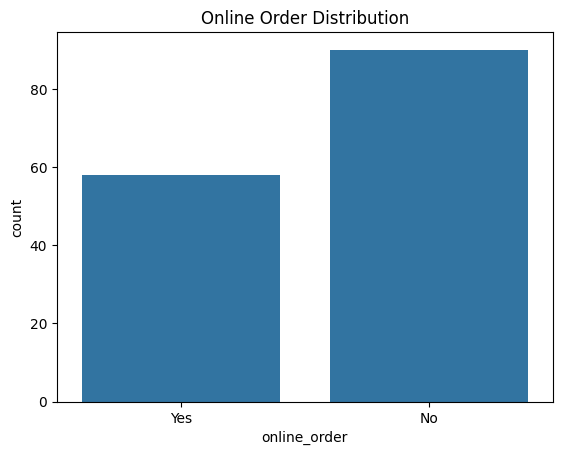

In [92]:
sns.countplot(x='online_order', data=df)
plt.title("Online Order Distribution")
plt.show()

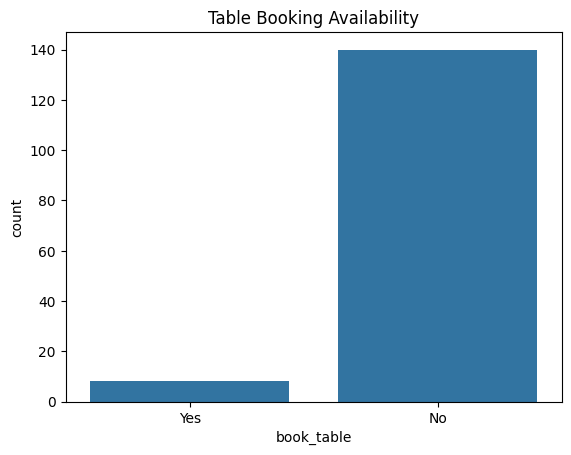

In [93]:
sns.countplot(x='book_table', data=df)
plt.title("Table Booking Availability")
plt.show()

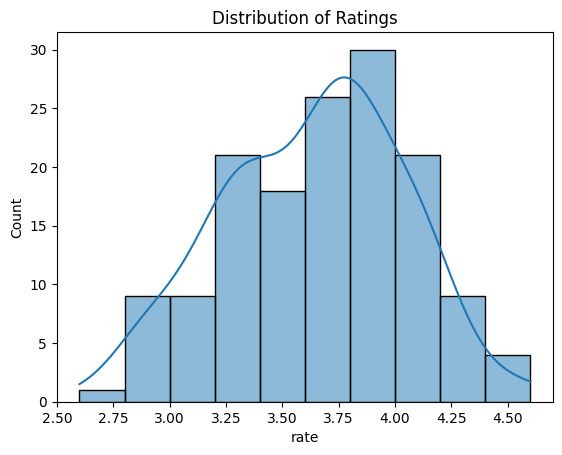

In [94]:
sns.histplot(df['rate'], bins=10, kde=True)
plt.title("Distribution of Ratings")
plt.show()

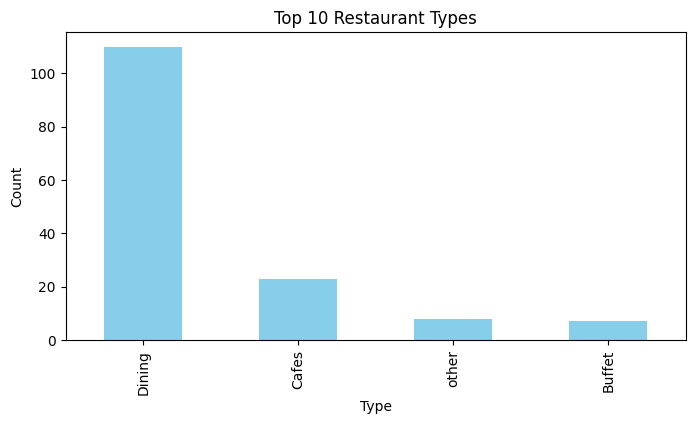

In [96]:
plt.figure(figsize=(8, 4))
df['listed_in(type)'].value_counts().head(10).plot(kind='bar', color='skyblue')
plt.title("Top 10 Restaurant Types")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

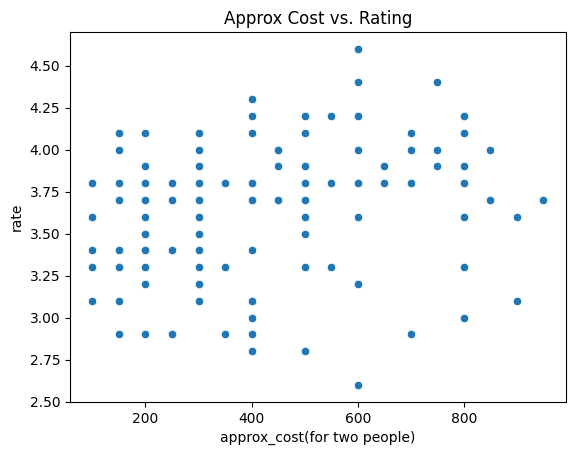

In [97]:
sns.scatterplot(x='approx_cost(for two people)', y='rate', data=df)
plt.title("Approx Cost vs. Rating")
plt.show()

In [98]:
print("Total Restaurants:", df.shape[0])
print("Average Rating:", round(df['rate'].mean(), 2))
print("Most Common Restaurant Type:", df['listed_in(type)'].mode()[0])
print("Most Common Locations:", df['listed_in(city)'].mode()[0] if 'listed_in(city)' in df.columns else "N/A")

Total Restaurants: 148
Average Rating: 3.63
Most Common Restaurant Type: Dining
Most Common Locations: N/A


In [99]:
print("""
Conclusion:
1. Most restaurant accept online orders.
2. Table booking is less common compared to online orders.
3. Average rating hovers around 3.5-4.0.
4. Cafe-type and Quick Bites restaurants dominate the dataset.
5. Cost and rating have a weak positive correlation - higher cost not always mean higher rating.
""")


Conclusion:
1. Most restaurant accept online orders.
2. Table booking is less common compared to online orders.
3. Average rating hovers around 3.5-4.0.
4. Cafe-type and Quick Bites restaurants dominate the dataset.
5. Cost and rating have a weak positive correlation - higher cost not always mean higher rating.



In [100]:
df.to_csv('cleaned_zomato.csv', index=False)
print("Cleaned dataset saved as 'cleaned_zomato.csv'")

Cleaned dataset saved as 'cleaned_zomato.csv'


In [101]:
from google.colab import files
files.download('cleaned_zomato.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>